# Deforestación Perú — Entrenar la U-Net

**Proyecto final MIA-07** — Detección de deforestación con U-Net.

Lee el split de `04_dataset_parches.ipynb` (`data/train/dataset_split.json`), reconstruye los `DataLoader`, entrena una **U-Net** que toma imágenes **4-band (R,G,B,NIR) 128×128** y predice una **máscara binaria** de deforestación.

- **Loss = Dice + BCE.** La deforestación es ~6% de los píxeles, así que la *accuracy* engaña (un modelo que dice "todo bosque" acierta el 94%). Dice mira el solape con la clase positiva; BCE estabiliza el entrenamiento.
- **Métricas en test: IoU y F1 sobre la clase deforestación**, no accuracy.
- Guardamos los mejores pesos por **IoU de validación**.

## 1. Dependencias y almacenamiento

In [1]:
!pip install -q rasterio opencv-python-headless torch segmentation-models-pytorch

from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    BASE_DIR = Path(".")

DATA_DIR   = BASE_DIR / "data"
SPLIT_PATH = DATA_DIR / "train" / "dataset_split.json"
CKPT_PATH  = DATA_DIR / "unet_best.pt"
print("Split:", SPLIT_PATH, "| existe:", SPLIT_PATH.exists())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00
Mounted at /content/drive
Split: /content/drive/MyDrive/deforestacion-peru/data/train/dataset_split.json | existe: True


## 2. Cargar el split y reconstruir los DataLoader

Reusamos exactamente el dataset de `04`: lee el `.tif` 4-band, normaliza dividiendo por 10000 (reflectancia L2A → [0,1]), redimensiona a 128×128 (imagen bilineal, máscara vecino más cercano) y aplica flips solo en train. El split ya viene decidido por escena en el JSON, así que no hay leakage.

In [2]:
import json
import numpy as np
import rasterio
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

SIZE = 128
pairs = json.loads(SPLIT_PATH.read_text())

class DeforestDataset(Dataset):
    def __init__(self, items, size=SIZE, augment=False):
        self.items = items
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        with rasterio.open(it["img"]) as src:
            img = src.read().astype("float32")          # (4, H, W)
        with rasterio.open(it["mask"]) as src:
            mask = src.read(1).astype("float32")         # (H, W)

        img = np.clip(img / 10000.0, 0, 1)               # reflectancia L2A -> [0,1]

        img = np.transpose(img, (1, 2, 0))               # (H,W,4) para cv2
        img = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.size, self.size), interpolation=cv2.INTER_NEAREST)

        if self.augment:
            if np.random.rand() < 0.5:
                img = img[:, ::-1, :].copy();  mask = mask[:, ::-1].copy()
            if np.random.rand() < 0.5:
                img = img[::-1, :, :].copy();  mask = mask[::-1, :].copy()

        img = torch.from_numpy(np.ascontiguousarray(np.transpose(img, (2, 0, 1))))  # (4,128,128)
        mask = torch.from_numpy(np.ascontiguousarray(mask)).unsqueeze(0)            # (1,128,128)
        return img, mask

def make_loader(split, batch_size=16, augment=False, shuffle=False):
    items = [p for p in pairs if p["split"] == split]
    ds = DeforestDataset(items, augment=augment)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2)

train_loader = make_loader("train", augment=True, shuffle=True)
val_loader   = make_loader("val")
test_loader  = make_loader("test")

from collections import Counter
c = Counter(p["split"] for p in pairs)
print(f"Pares: {len(pairs)} | train={c['train']} val={c['val']} test={c['test']}")

# fracción de píxeles positivos en train -> sirve para pos_weight de BCE
pos = tot = 0
for _, yb in train_loader:
    pos += float(yb.sum()); tot += yb.numel()
frac = pos / tot
print(f"% píxeles deforestados en train: {100*frac:.2f}%")

Pares: 624 | train=437 val=94 test=93
% píxeles deforestados en train: 4.23%


## 3. La U-Net (encoder ResNet34 pre-entrenado)

Usamos `segmentation-models-pytorch` (smp) para armar una **U-Net con encoder ResNet34 pre-entrenado en ImageNet** (transfer learning):

- **Encoder = ResNet34** ya entrenado en ImageNet → arranca sabiendo detectar bordes, texturas y formas. No reaprende eso desde cero.
- **Entrada: 4 canales** (R, G, B, NIR). El encoder original es RGB (3 canales); smp adapta el primer conv a 4 canales automáticamente (`in_channels=4`), inicializando la banda extra (NIR) desde los pesos pre-entrenados.
- **Salida: 1 canal** (logits). `sigmoid` al evaluar.
- El **decoder** sí se entrena desde cero — es el que aprende a marcar deforestación con tus datos.

Frente a una U-Net desde cero, esto suele dar **mejor IoU con menos epochs**, sobre todo con datasets medianos como el tuyo (~1800 pares).

In [3]:
import torch.nn as nn
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",        # encoder ResNet34
    encoder_weights="imagenet",     # pre-entrenado en ImageNet (transfer learning)
    in_channels=4,                  # R, G, B, NIR (smp adapta el 1er conv de 3->4)
    classes=1,                      # 1 máscara binaria (logits)
).to(device)

# nota: smp normalmente espera input normalizado con mean/std de ImageNet, pero
# como hacemos fine-tuning y el encoder tiene BatchNorm, normalizar a [0,1]
# (dividir por 10000) funciona bien. El modelo se adapta durante el entrenamiento.

n_par = sum(p.numel() for p in model.parameters())
n_train_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device} | parámetros: {n_par/1e6:.2f} M (entrenables: {n_train_par/1e6:.2f} M)")

# sanity check: forward de un batch
with torch.no_grad():
    xb, _ = next(iter(val_loader))
    out = model(xb.to(device))
print("salida del modelo:", tuple(out.shape))   # esperado (B,1,128,128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Device: cuda | parámetros: 24.44 M (entrenables: 24.44 M)
salida del modelo: (16, 1, 128, 128)


## 4. Loss (Dice + BCE) y métricas

- **BCE con `pos_weight`**: pesa más los píxeles positivos (raros) para que el modelo no aprenda a apagar todo.
- **Dice loss**: `1 - 2|A∩B| / (|A|+|B|)`, optimiza directamente el solape con la clase deforestación.
- **Métricas** (sobre la clase positiva, con umbral 0.5): IoU, F1, precision, recall. Las calculamos acumulando intersección y unión sobre todo el set — no promediando por batch — para que sea el valor real del dataset.

In [4]:
class DiceBCELoss(nn.Module):
    def __init__(self, pos_weight=None, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.smooth = smooth
    def forward(self, logits, target):
        bce = self.bce(logits, target)
        prob = torch.sigmoid(logits)
        num = 2 * (prob * target).sum(dim=(1,2,3)) + self.smooth
        den = prob.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + self.smooth
        dice = 1 - (num / den).mean()
        return bce + dice

# pos_weight = (neg/pos): cuántas veces más raro es el positivo
pw = torch.tensor([(1 - frac) / max(frac, 1e-6)], device=device)
criterion = DiceBCELoss(pos_weight=pw)
print("pos_weight:", round(float(pw), 1))

@torch.no_grad()
def evaluate(loader, thr=0.5):
    model.eval()
    inter = union = tp = fp = fn = 0.0
    loss_sum = n = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss_sum += float(criterion(logits, yb)) * xb.size(0); n += xb.size(0)
        pred = (torch.sigmoid(logits) > thr).float()
        inter += float((pred * yb).sum())
        union += float(((pred + yb) >= 1).sum())
        tp += float((pred * yb).sum())
        fp += float((pred * (1 - yb)).sum())
        fn += float(((1 - pred) * yb).sum())
    iou  = inter / (union + 1e-6)
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    return {"loss": loss_sum / n, "iou": iou, "f1": f1, "precision": prec, "recall": rec}

pos_weight: 22.6


## 5. Entrenamiento

Adam + scheduler que baja el LR cuando el IoU de validación se estanca. Guardamos los pesos del **mejor IoU de validación** (no del último epoch) en `data/unet_best.pt`.

In [5]:
EPOCHS = 40
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=4)

history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}
best_iou = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    run = n = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        opt.step()
        run += float(loss) * xb.size(0); n += xb.size(0)
    tr_loss = run / n

    val = evaluate(val_loader)
    sched.step(val["iou"])
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val["loss"])
    history["val_iou"].append(val["iou"])
    history["val_f1"].append(val["f1"])

    flag = ""
    if val["iou"] > best_iou:
        best_iou = val["iou"]
        torch.save(model.state_dict(), str(CKPT_PATH))
        flag = "  <- mejor (guardado)"
    print(f"epoch {epoch:2d} | train {tr_loss:.3f} | val loss {val['loss']:.3f} "
          f"IoU {val['iou']:.3f} F1 {val['f1']:.3f}{flag}")

print(f"\nMejor IoU val: {best_iou:.3f} -> {CKPT_PATH}")

/tmp/ipykernel_895/1978310077.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  run += float(loss) * xb.size(0); n += xb.size(0)


epoch  1 | train 1.897 | val loss 2.876 IoU 0.081 F1 0.150  <- mejor (guardado)
epoch  2 | train 1.515 | val loss 2.223 IoU 0.316 F1 0.480  <- mejor (guardado)
epoch  3 | train 1.426 | val loss 1.753 IoU 0.259 F1 0.412
epoch  4 | train 1.386 | val loss 1.730 IoU 0.201 F1 0.335
epoch  5 | train 1.344 | val loss 1.893 IoU 0.325 F1 0.490  <- mejor (guardado)
epoch  6 | train 1.344 | val loss 2.237 IoU 0.304 F1 0.467
epoch  7 | train 1.331 | val loss 1.812 IoU 0.297 F1 0.458
epoch  8 | train 1.324 | val loss 2.528 IoU 0.352 F1 0.521  <- mejor (guardado)
epoch  9 | train 1.324 | val loss 1.711 IoU 0.251 F1 0.402
epoch 10 | train 1.294 | val loss 1.910 IoU 0.322 F1 0.487
epoch 11 | train 1.300 | val loss 2.072 IoU 0.261 F1 0.414
epoch 12 | train 1.272 | val loss 1.669 IoU 0.320 F1 0.485
epoch 13 | train 1.285 | val loss 1.677 IoU 0.268 F1 0.423
epoch 14 | train 1.250 | val loss 1.670 IoU 0.329 F1 0.496
epoch 15 | train 1.218 | val loss 1.852 IoU 0.347 F1 0.515
epoch 16 | train 1.212 | val lo

## 6. Curvas de entrenamiento

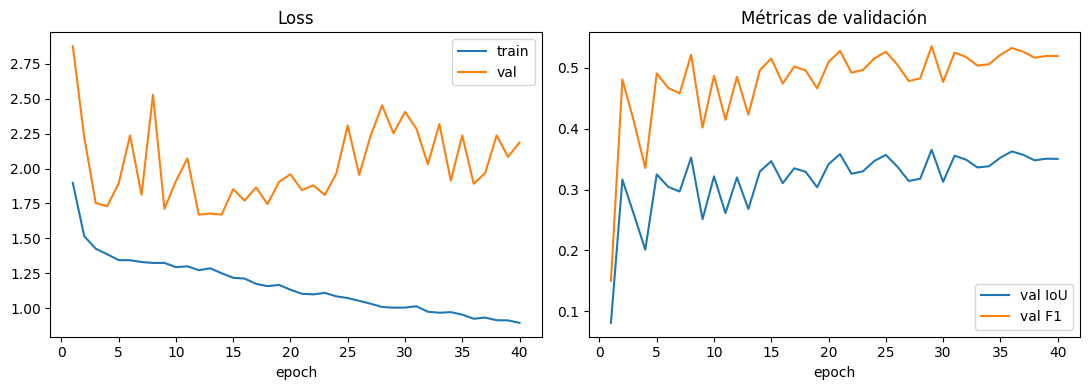

In [6]:
import matplotlib.pyplot as plt

ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, history["val_iou"], label="val IoU")
ax[1].plot(ep, history["val_f1"], label="val F1")
ax[1].set_title("Métricas de validación"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(str(DATA_DIR / "unet_curvas.png"), dpi=110, bbox_inches="tight"); plt.show()

## 7. Evaluación en test

Cargamos los mejores pesos y medimos sobre el set de test (escenas que el modelo nunca vio). Estos son los números que reportas.

In [7]:
model.load_state_dict(torch.load(str(CKPT_PATH), map_location=device))
test = evaluate(test_loader)
print("=== TEST (clase deforestación) ===")
for k in ["iou", "f1", "precision", "recall", "loss"]:
    print(f"  {k:10s}: {test[k]:.3f}")

=== TEST (clase deforestación) ===
  iou       : 0.293
  f1        : 0.453
  precision : 0.314
  recall    : 0.815
  loss      : 1.194


### Barrido de umbral

El umbral 0.5 no siempre es el mejor para clases desbalanceadas. Probamos varios y vemos cuál maximiza el F1 — útil si quieres priorizar recall (no perder deforestación) sobre precision.

In [8]:
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    m = evaluate(test_loader, thr=thr)
    print(f"thr {thr:.1f} | IoU {m['iou']:.3f} F1 {m['f1']:.3f} "
          f"P {m['precision']:.3f} R {m['recall']:.3f}")

thr 0.3 | IoU 0.260 F1 0.413 P 0.272 R 0.858
thr 0.4 | IoU 0.277 F1 0.434 P 0.293 R 0.837
thr 0.5 | IoU 0.293 F1 0.453 P 0.314 R 0.815
thr 0.6 | IoU 0.308 F1 0.470 P 0.335 R 0.790
thr 0.7 | IoU 0.322 F1 0.487 P 0.359 R 0.756


## 8. Predicciones visuales (test)

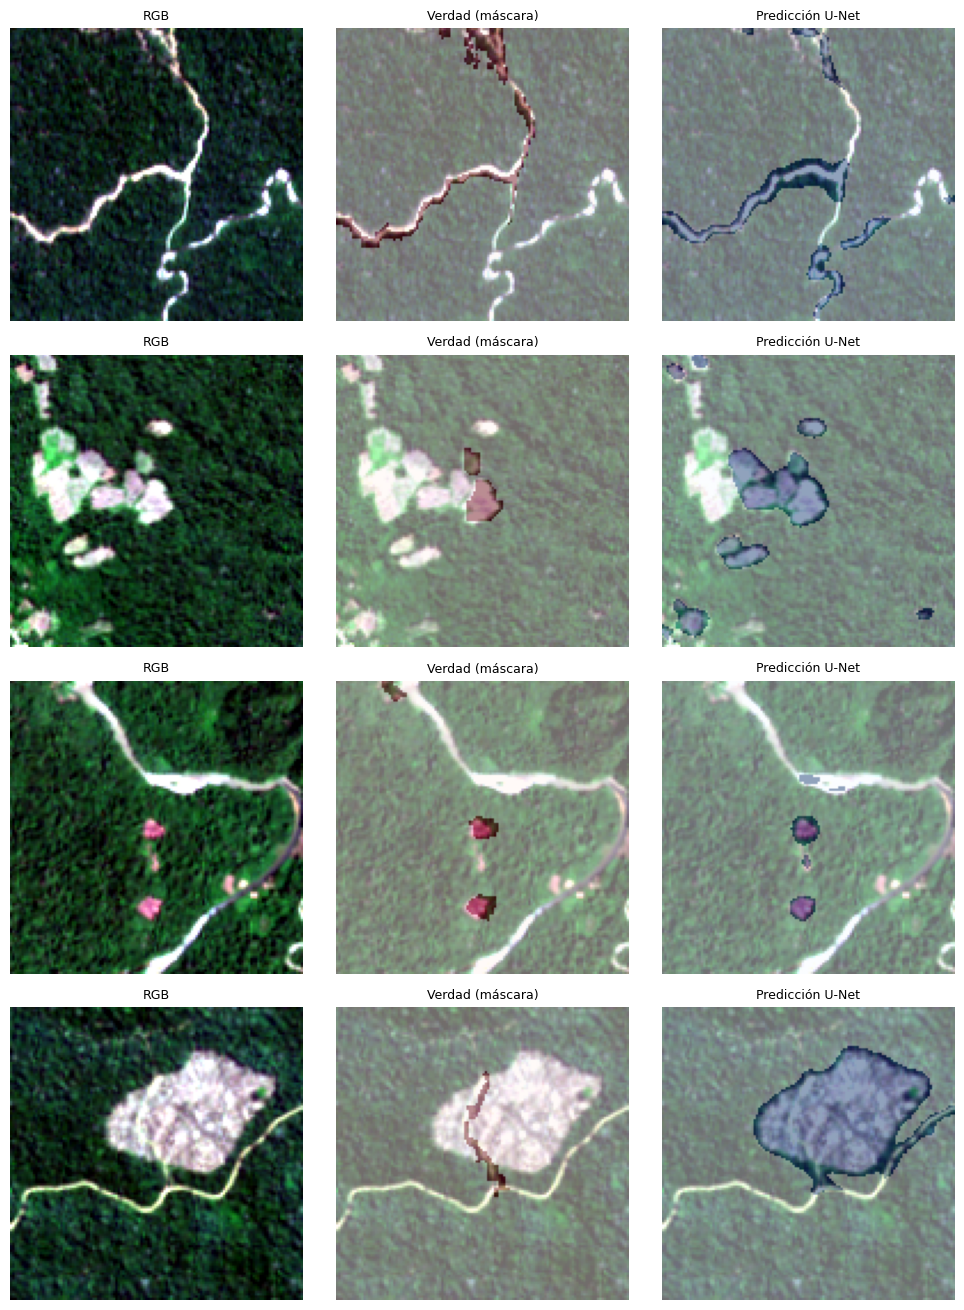

In [9]:
def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    pred = (torch.sigmoid(model(xb.to(device))) > 0.5).float().cpu()

k = min(4, xb.shape[0])
fig, axes = plt.subplots(k, 3, figsize=(10, 3.3 * k))
axes = np.atleast_2d(axes)
for row, img, gt, pr in zip(axes, xb[:k], yb[:k], pred[:k]):
    arr = img.numpy()
    rgb = np.dstack([stretch(arr[c]) for c in range(3)])
    row[0].imshow(rgb); row[0].set_title("RGB", fontsize=9)
    row[1].imshow(rgb); row[1].imshow(gt[0], cmap="Reds", alpha=0.45, vmin=0, vmax=1)
    row[1].set_title("Verdad (máscara)", fontsize=9)
    row[2].imshow(rgb); row[2].imshow(pr[0], cmap="Blues", alpha=0.45, vmin=0, vmax=1)
    row[2].set_title("Predicción U-Net", fontsize=9)
    for a in row: a.axis("off")
plt.tight_layout(); plt.savefig(str(DATA_DIR / "unet_pred_muestra.png"), dpi=110, bbox_inches="tight"); plt.show()

## 9. Próximos pasos

Modelo entrenado y evaluado. Pesos en `data/unet_best.pt`.

- **NDVI como 5ta banda**: `(NIR - R) / (NIR + R)` separa bosque vivo de suelo desnudo; suele subir el IoU. Cambiarías `in_ch=5` en la U-Net y agregarías la banda en el dataset.
- **Más augmentation**: rotaciones 90°, pequeños cambios de brillo.
- **Encoder más grande** (resnet50, efficientnet-b0) si el IoU se estanca y la GPU aguanta. Solo cambias `encoder_name`.
- **Comparar contra U-Net desde cero**: entrena las dos y pon una tabla IoU/F1 — buen argumento para la tesis (muestra que transfer learning ayuda).
- **Análisis de errores**: mirar las escenas de test con peor IoU — suelen ser nubes o bordes de polígono mal rasterizados en `03`.